# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Rafa Rizki Aira Swala| 5054251017|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

# Setting tampilan
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
# Load dataset dan tampilkan informasi dasar:
# jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('diabetes.csv')

print("JUMLAH BARIS DAN KOLOM")
print(f"Jumlah baris : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")

print("\nLIMA DATA TERATAS")
display(df.head())

print("\nTIPE DATA & INFO DATASET")
df.info()

print("\nSTATISTIK DESKRIPTIF")
display(df.describe())

print("\nJUMLAH MISSING VALUE PER KOLOM")
print(df.isnull().sum())

print("\nJUMLAH DATA DUPLIKAT")
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

JUMLAH BARIS DAN KOLOM
Jumlah baris : 768
Jumlah kolom : 9

LIMA DATA TERATAS


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



TIPE DATA & INFO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

STATISTIK DESKRIPTIF


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



JUMLAH MISSING VALUE PER KOLOM
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

JUMLAH DATA DUPLIKAT
Jumlah data duplikat: 0


DISTRIBUSI KELAS TARGET (Outcome)
Jumlah per kelas:
Outcome
0    500
1    268
Name: count, dtype: int64

Proporsi per kelas:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


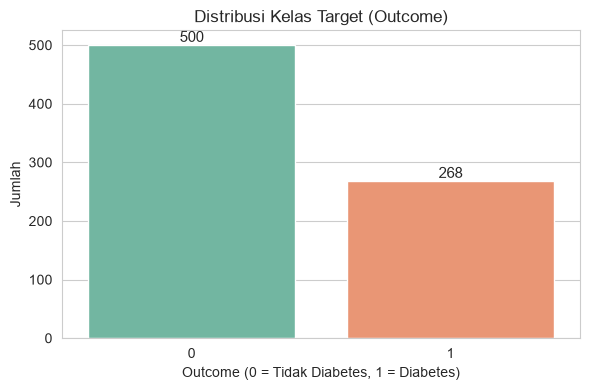


Rasio kelas 0 : kelas 1 = 0.6510 : 0.3490
>> Dataset ini IMBALANCED (kelas minoritas < 40%).


In [3]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
print("DISTRIBUSI KELAS TARGET (Outcome)")
print("Jumlah per kelas:")
print(df['Outcome'].value_counts())
print("\nProporsi per kelas:")
print(df['Outcome'].value_counts(normalize=True).round(4))

# Bar plot distribusi kelas target
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Distribusi Kelas Target (Outcome)')
plt.xlabel('Outcome (0 = Tidak Diabetes, 1 = Diabetes)')
plt.ylabel('Jumlah')

# Tambahkan label jumlah di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Interpretasi imbalance
ratio = df['Outcome'].value_counts(normalize=True)
print(f"\nRasio kelas 0 : kelas 1 = {ratio[0]:.4f} : {ratio[1]:.4f}")
if ratio.min() < 0.4:
    print(">> Dataset ini IMBALANCED (kelas minoritas < 40%).")
else:
    print(">> Dataset ini relatif SEIMBANG.")

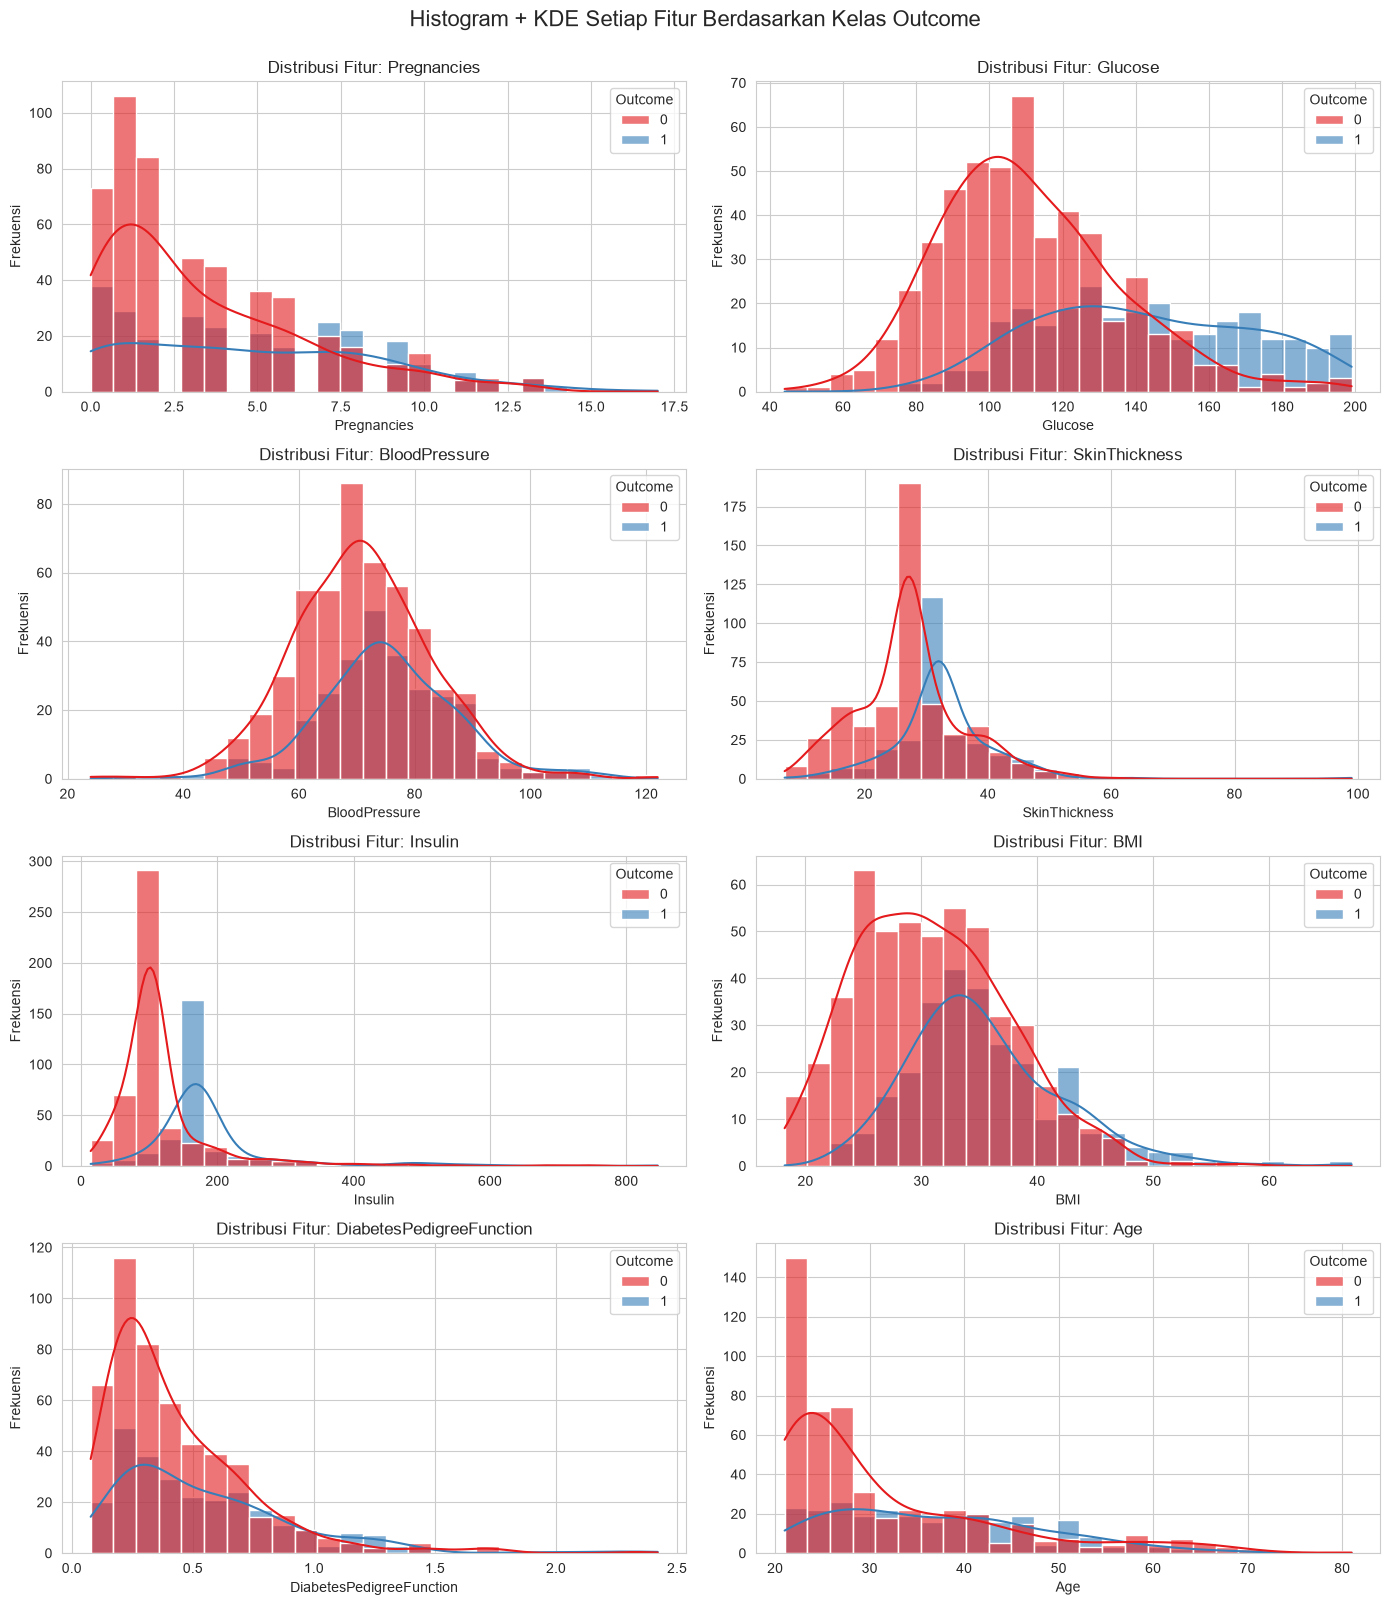

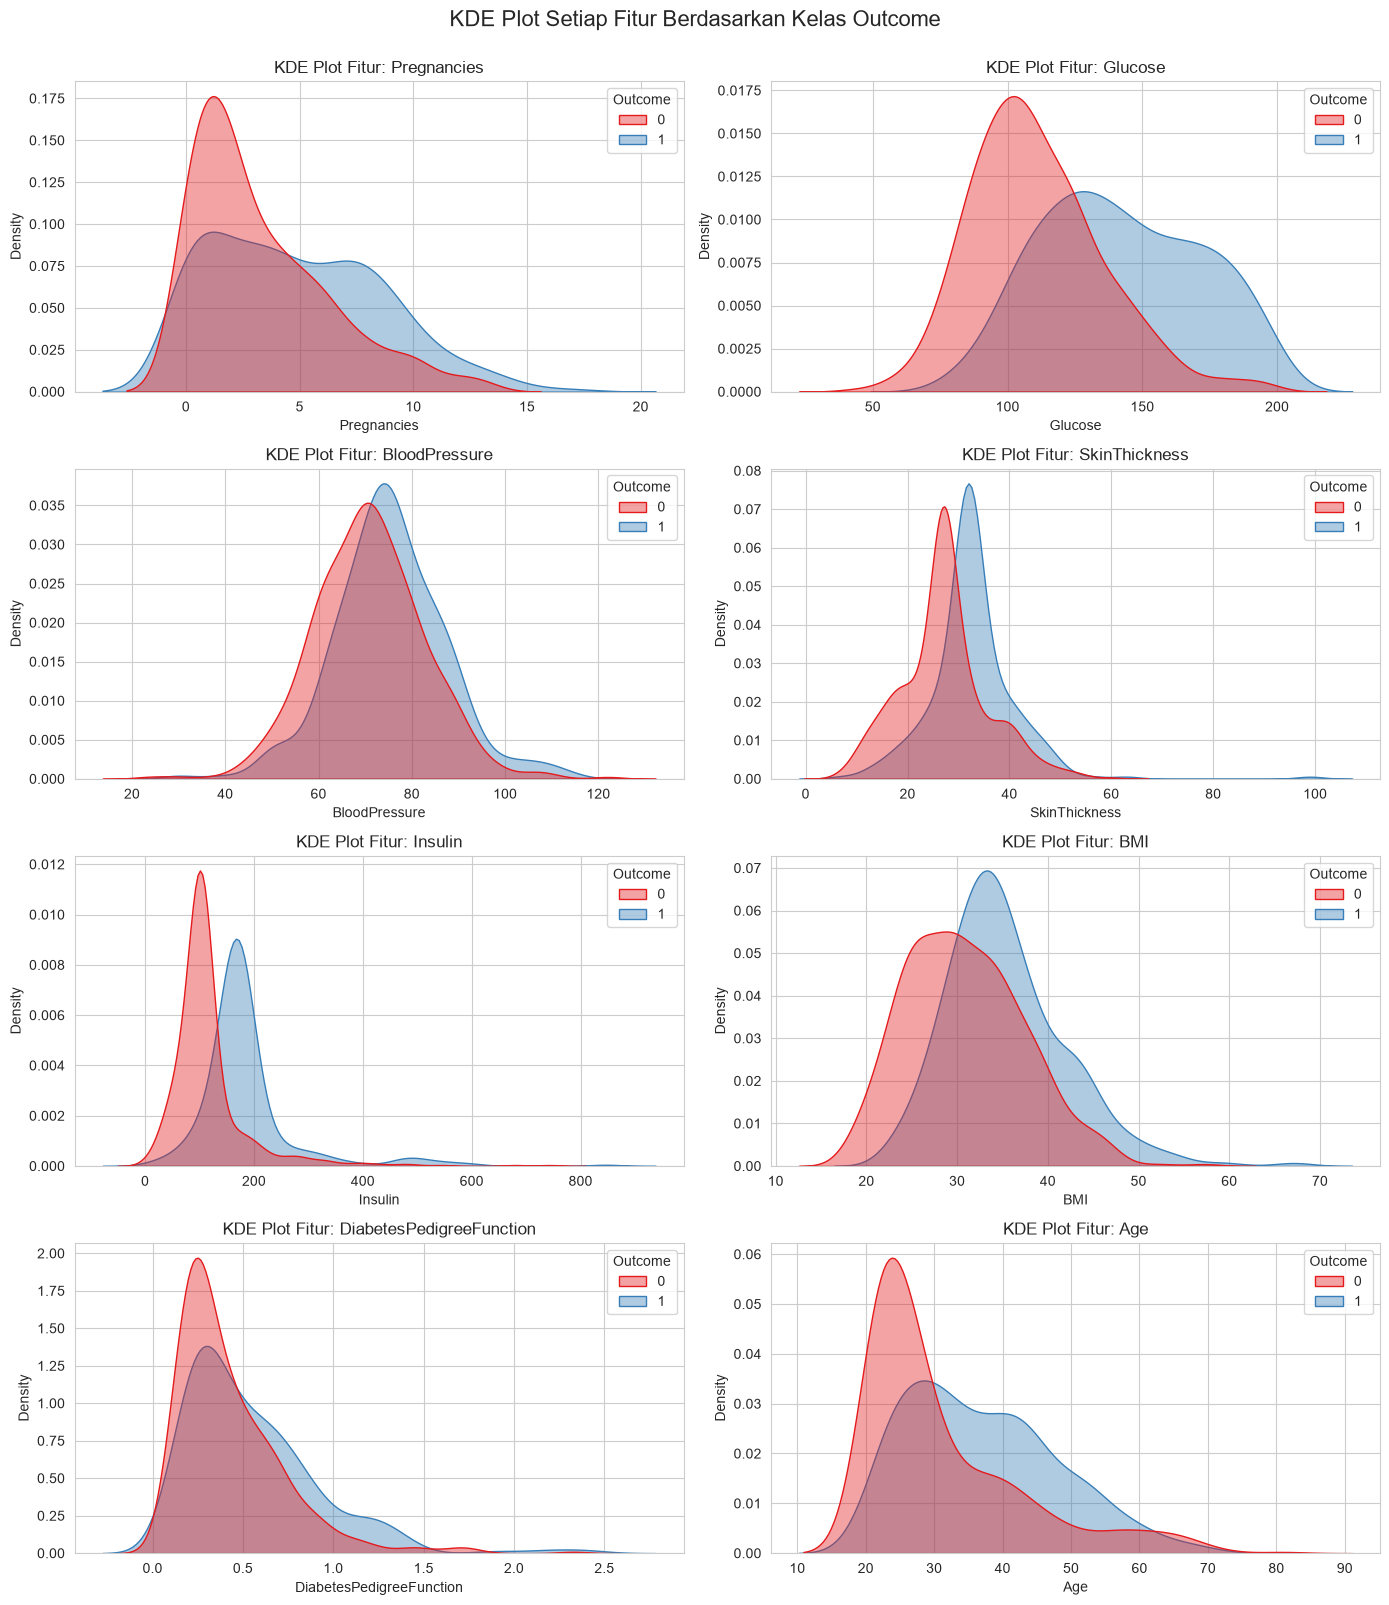

In [4]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot,
# dibedakan berdasarkan kelas Outcome.
features = [col for col in df.columns if col != 'Outcome']

# 4a. Histogram per fitur (dibedakan berdasarkan Outcome)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True,
                 palette='Set1', ax=axes[i], alpha=0.6, bins=25)
    axes[i].set_title(f'Distribusi Fitur: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Histogram + KDE Setiap Fitur Berdasarkan Kelas Outcome', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

# 4b. KDE plot per fitur (lebih halus, dibedakan berdasarkan Outcome)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue='Outcome', palette='Set1',
                fill=True, alpha=0.4, ax=axes[i], common_norm=False)
    axes[i].set_title(f'KDE Plot Fitur: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

plt.suptitle('KDE Plot Setiap Fitur Berdasarkan Kelas Outcome', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

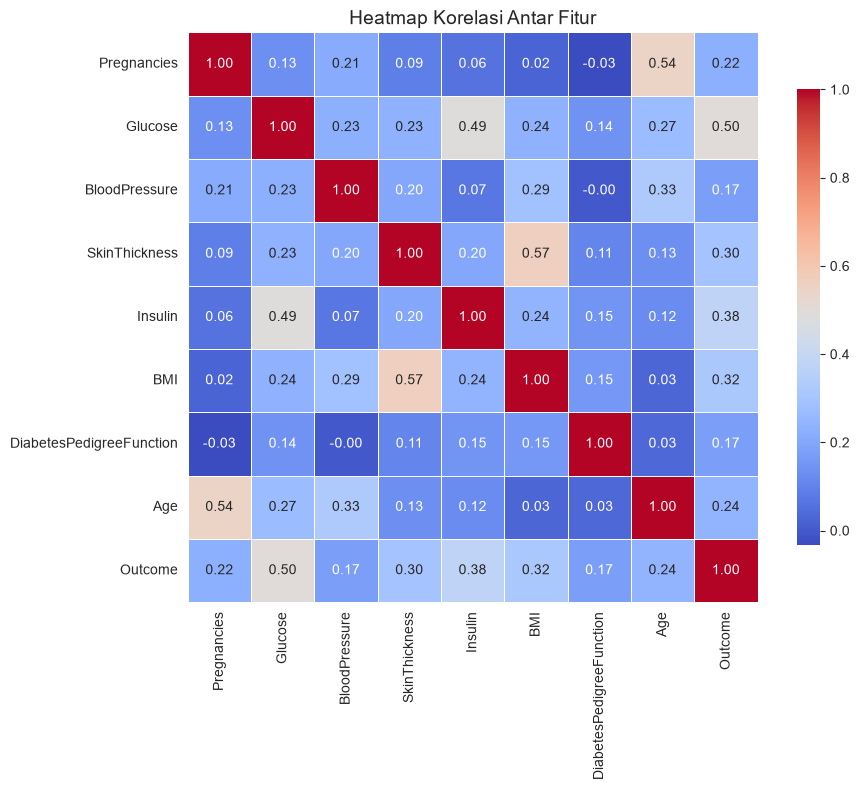

KORELASI FITUR TERHADAP TARGET (Outcome)
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


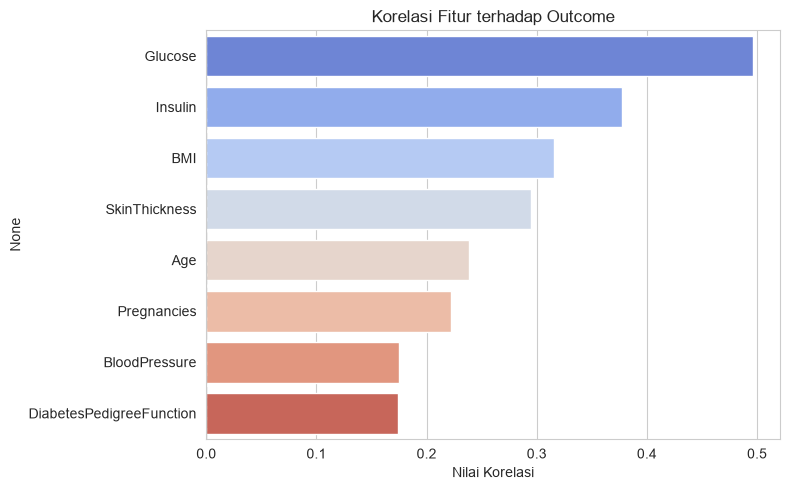

In [5]:
# Tampilkan heatmap korelasi antar fitur.
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()

# Tampilkan korelasi fitur terhadap target Outcome (diurutkan)
print("KORELASI FITUR TERHADAP TARGET (Outcome)")
corr_target = corr_matrix['Outcome'].drop('Outcome').sort_values(ascending=False)
print(corr_target)

# Visualisasi korelasi terhadap target
plt.figure(figsize=(8, 5))
sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')
plt.title('Korelasi Fitur terhadap Outcome')
plt.xlabel('Nilai Korelasi')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

JUMLAH NILAI 0 PADA KOLOM YANG SECARA MEDIS TIDAK MUNGKIN 0
-------------------------------------------------------
Glucose         :    0 nilai 0 (0.00%)
BloodPressure   :    0 nilai 0 (0.00%)
SkinThickness   :    0 nilai 0 (0.00%)
Insulin         :    0 nilai 0 (0.00%)
BMI             :    0 nilai 0 (0.00%)
-------------------------------------------------------
Total baris dataset: 768


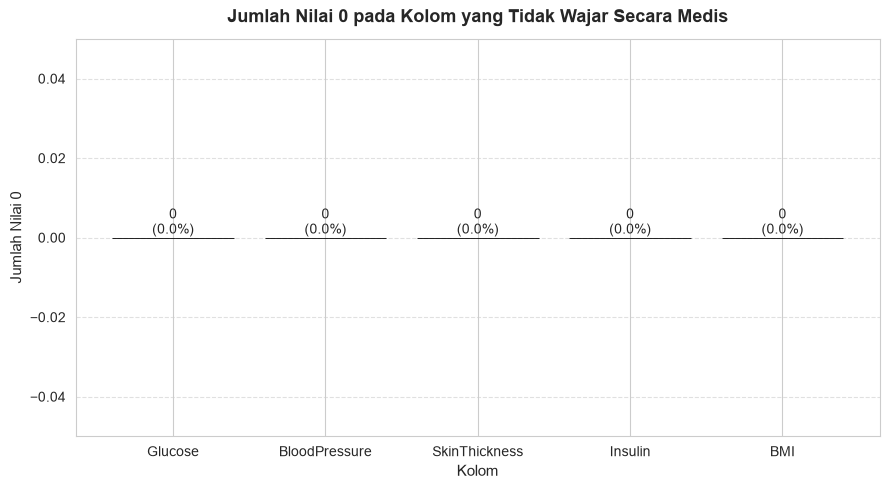

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pastikan style bersih
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

cols_zero_invalid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# ==== 1. Hitung & tampilkan tabel ====
print("JUMLAH NILAI 0 PADA KOLOM YANG SECARA MEDIS TIDAK MUNGKIN 0")
print("-" * 55)
summary = []
for col in cols_zero_invalid:
    zero_count = (df[col] == 0).sum()
    zero_pct = zero_count / len(df) * 100
    summary.append({'Kolom': col, 'Jumlah 0': zero_count, 'Persentase (%)': round(zero_pct, 2)})
    print(f"{col:15s} : {zero_count:4d} nilai 0 ({zero_pct:.2f}%)")

print("-" * 55)
print("Total baris dataset:", len(df))

# ==== 2. Visualisasi ====
zero_counts = pd.Series({col: (df[col] == 0).sum() for col in cols_zero_invalid})
zero_pct    = (zero_counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 5))   # <-- ukuran proporsional
bars = ax.bar(zero_counts.index, zero_counts.values,
              color=sns.color_palette("Reds", len(zero_counts)),
              edgecolor='black', linewidth=0.6)

# Label nilai + persentase di atas bar
for bar, val, pct in zip(bars, zero_counts.values, zero_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(zero_counts)*0.02,
            f"{val}\n({pct}%)", ha='center', va='bottom', fontsize=10)

ax.set_title('Jumlah Nilai 0 pada Kolom yang Tidak Wajar Secara Medis',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Kolom', fontsize=11)
ax.set_ylabel('Jumlah Nilai 0', fontsize=11)
ax.set_ylim(0, max(zero_counts.values) * 1.15)   # <-- beri ruang atas
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [10]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai
# (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

# PENTING: median dihitung HANYA dari data non-zero, dan kita akan menggunakan
# nilai median dari TRAIN SET saja saat imputasi nanti (lihat catatan di bawah).
# Untuk eksplorasi awal, kita tampilkan median dari seluruh data non-zero dulu.

df_clean = df.copy()

print("MEDIAN DARI DATA NON-ZERO (hanya untuk eksplorasi):")
medians_overall = {}
for col in cols_zero_invalid:
    median_val = df_clean.loc[df_clean[col] != 0, col].median()
    medians_overall[col] = median_val
    print(f"{col:15s} : {median_val:.2f}")

# Catatan data leakage:
# Idealnya median dihitung dari train set saja. Namun karena kita belum split,
# kita akan lakukan imputasi setelah split di cell berikutnya.
# Di sini kita simpan dulu dataframe tanpa imputasi agar tidak bocor.
print("\nDataframe df_clean disiapkan TANPA imputasi (imputasi dilakukan setelah split).")

MEDIAN DARI DATA NON-ZERO (hanya untuk eksplorasi):
Glucose         : 117.00
BloodPressure   : 72.00
SkinThickness   : 28.00
Insulin         : 102.50
BMI             : 32.05

Dataframe df_clean disiapkan TANPA imputasi (imputasi dilakukan setelah split).


In [11]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

# Pisahkan fitur dan target (masih dari df_clean yang belum diimputasi)
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

print("Shape X :", X.shape)
print("Shape y :", y.shape)
print("Nama fitur:", list(X.columns))

# Train-test split dengan stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nShape X_train :", X_train.shape)
print("Shape X_test  :", X_test.shape)
print("Shape y_train :", y_train.shape)
print("Shape y_test  :", y_test.shape)

# Cek proporsi kelas di train & test
print("\nProporsi kelas di y_train:")
print(y_train.value_counts(normalize=True).round(4))
print("\nProporsi kelas di y_test:")
print(y_test.value_counts(normalize=True).round(4))

# Imputasi nilai 0 dengan median DARI TRAIN SET (mencegah data leakage)
X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

print("\nIMPUTASI NILAI 0 DENGAN MEDIAN DARI TRAIN SET:")
for col in cols_zero_invalid:
    median_train = X_train_imputed.loc[X_train_imputed[col] != 0, col].median()
    X_train_imputed[col] = X_train_imputed[col].replace(0, median_train)
    X_test_imputed[col] = X_test_imputed[col].replace(0, median_train)
    print(f"{col:15s} : median train = {median_train:.2f}")

# Verifikasi tidak ada lagi nilai 0 di kolom tersebut
print("\nCek sisa nilai 0 setelah imputasi:")
print("Pada X_train:")
for col in cols_zero_invalid:
    print(f"  {col:15s} : {(X_train_imputed[col] == 0).sum()}")
print("Pada X_test:")
for col in cols_zero_invalid:
    print(f"  {col:15s} : {(X_test_imputed[col] == 0).sum()}")

Shape X : (768, 8)
Shape y : (768,)
Nama fitur: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Shape X_train : (614, 8)
Shape X_test  : (154, 8)
Shape y_train : (614,)
Shape y_test  : (154,)

Proporsi kelas di y_train:
Outcome
0    0.6515
1    0.3485
Name: proportion, dtype: float64

Proporsi kelas di y_test:
Outcome
0    0.6494
1    0.3506
Name: proportion, dtype: float64

IMPUTASI NILAI 0 DENGAN MEDIAN DARI TRAIN SET:
Glucose         : median train = 117.00
BloodPressure   : median train = 72.00
SkinThickness   : median train = 28.00
Insulin         : median train = 102.50
BMI             : median train = 32.40

Cek sisa nilai 0 setelah imputasi:
Pada X_train:
  Glucose         : 0
  BloodPressure   : 0
  SkinThickness   : 0
  Insulin         : 0
  BMI             : 0
Pada X_test:
  Glucose         : 0
  BloodPressure   : 0
  SkinThickness   : 0
  Insulin         : 0
  BMI             : 0


In [12]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.

scaler = StandardScaler()

# Fit hanya pada train set
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Transform pada train set dan test set
X_test_scaled = scaler.transform(X_test_imputed)

print("Contoh data X_train SEBELUM scaling:")
print(X_train_imputed.head(3))

print("\nContoh data X_train SESUDAH scaling:")
print(pd.DataFrame(X_train_scaled, columns=X.columns).head(3))

print("\nStatistik X_train setelah scaling (mean ~0, std ~1):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).describe().loc[['mean', 'std']].round(4))

print("\nShape X_train_scaled :", X_train_scaled.shape)
print("Shape X_test_scaled  :", X_test_scaled.shape)

Contoh data X_train SEBELUM scaling:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
353            1       90           62.0             12     43.0  27.2   
711            5      126           78.0             27     22.0  29.6   
373            2      105           58.0             40     94.0  34.9   

     DiabetesPedigreeFunction  Age  
353                     0.580   24  
711                     0.439   40  
373                     0.225   25  

Contoh data X_train SESUDAH scaling:
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -0.851355 -1.056869      -0.826687      -1.895290 -1.170378 -0.766150   
1     0.356576  0.142855       0.477009      -0.224736 -1.427642 -0.414448   
2    -0.549372 -0.556984      -1.152611       1.223078 -0.545594  0.362227   

   DiabetesPedigreeFunction       Age  
0                  0.310794 -0.792169  
1                 -0.116439  0.561034  
2                 -0.764862 -0.707594  

Statis

# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [13]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

print("Model Gaussian Naive Bayes selesai dilatih.")
print("Jumlah fitur :", gnb.n_features_in_)
print("Kelas        :", gnb.classes_)

Model Gaussian Naive Bayes selesai dilatih.
Jumlah fitur : 8
Kelas        : [0 1]


In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gnb = gnb.predict(X_test_scaled)
y_prob_gnb = gnb.predict_proba(X_test_scaled)[:, 1]

print("Hasil prediksi label (10 pertama) :", y_pred_gnb[:10])
print("Probabilitas kelas 1 (10 pertama) :", np.round(y_prob_gnb[:10], 4))
print("\nShape y_pred_gnb :", y_pred_gnb.shape)
print("Shape y_prob_gnb :", y_prob_gnb.shape)

Hasil prediksi label (10 pertama) : [0 0 0 0 0 0 1 1 0 1]
Probabilitas kelas 1 (10 pertama) : [0.3946 0.2109 0.2328 0.1853 0.0061 0.0273 0.8558 0.9975 0.0062 0.9946]

Shape y_pred_gnb : (154,)
Shape y_prob_gnb : (154,)


## 3.2 Logistic Regression

In [15]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

print("Model Logistic Regression selesai dilatih.")
print("Jumlah fitur :", logreg.n_features_in_)
print("Kelas        :", logreg.classes_)
print("Iterasi      :", logreg.n_iter_)

Model Logistic Regression selesai dilatih.
Jumlah fitur : 8
Kelas        : [0 1]
Iterasi      : [8]


In [16]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_logreg = logreg.predict(X_test_scaled)
y_prob_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

print("Hasil prediksi label (10 pertama) :", y_pred_logreg[:10])
print("Probabilitas kelas 1 (10 pertama) :", np.round(y_prob_logreg[:10], 4))
print("\nShape y_pred_logreg :", y_pred_logreg.shape)
print("Shape y_prob_logreg :", y_prob_logreg.shape)

Hasil prediksi label (10 pertama) : [0 0 0 0 0 0 1 1 0 1]
Probabilitas kelas 1 (10 pertama) : [0.4774 0.0741 0.3701 0.3377 0.032  0.1035 0.5598 0.902  0.0672 0.9042]

Shape y_pred_logreg : (154,)
Shape y_prob_logreg : (154,)


# 4. Evaluasi Model

In [ ]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model'     : model_name,
        'Accuracy'  : accuracy_score(y_true, y_pred),
        'Precision' : precision_score(y_true, y_pred),
        'Recall'    : recall_score(y_true, y_pred),
        'F1-Score'  : f1_score(y_true, y_pred)
    }

metrics_gnb    = get_metrics(y_test, y_pred_gnb, 'Gaussian Naive Bayes')
metrics_logreg = get_metrics(y_test, y_pred_logreg, 'Logistic Regression')

metrics_df = pd.DataFrame([metrics_gnb, metrics_logreg]).set_index('Model')
print("TABEL METRIK EVALUASI")
print(metrics_df.round(4))

print("\nCLASSIFICATION REPORT - Gaussian Naive Bayes")
print(classification_report(y_test, y_pred_gnb, target_names=['Tidak Diabetes', 'Diabetes']))

print("CLASSIFICATION REPORT - Logistic Regression")
print(classification_report(y_test, y_pred_logreg, target_names=['Tidak Diabetes', 'Diabetes']))

In [ ]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_gnb = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Tidak Diabetes', 'Diabetes'],
            yticklabels=['Tidak Diabetes', 'Diabetes'])
axes[0].set_title('Confusion Matrix - Gaussian Naive Bayes')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Tidak Diabetes', 'Diabetes'],
            yticklabels=['Tidak Diabetes', 'Diabetes'])
axes[1].set_title('Confusion Matrix - Logistic Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : logreg.coef_[0]
}).sort_values(by='Koefisien', key=lambda s: s.abs(), ascending=True)

print("KOEFISIEN FITUR LOGISTIC REGRESSION (diurutkan berdasarkan |koefisien|)")
print(coef_df.sort_values(by='Koefisien', key=lambda s: s.abs(), ascending=False).to_string(index=False))

colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Koefisien']]

plt.figure(figsize=(9, 6))
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Koefisien Fitur - Logistic Regression')
plt.xlabel('Nilai Koefisien (positif = meningkatkan risiko diabetes)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

In [ ]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.